# Uczenie maszynowe 1
## Pracownia specjalistyczna nr 1
### Wprowadzenie do analizy danych w Pythonie: NumPy, pandas i Matplotlib


**Uwaga:** zbiór `mieszkania_dydaktyczne.csv` został przygotowany wyłącznie do celów dydaktycznych.  
Wartości nie opisują aktualnego rynku nieruchomości.


## Cele zajęć

Po wykonaniu ćwiczeń student powinien potrafić:

- utworzyć tablicę `NumPy` i wykonać na niej podstawowe operacje,
- odczytać dane z pliku CSV do obiektu `DataFrame`,
- rozpoznać obserwacje i cechy w danych tabelarycznych,
- sprawdzić strukturę i podstawowe statystyki zbioru danych,
- wybierać kolumny i wiersze oraz filtrować obserwacje,
- tworzyć nowe kolumny i wykonywać proste agregacje,
- wykryć brakujące wartości,
- przedstawić dane na histogramie, wykresie punktowym i słupkowym,
- sformułować proste wnioski na podstawie danych i wykresów.

## 1. Import bibliotek

W analizie danych bardzo często spotkamy poniższe skróty:

- `np` — NumPy,
- `pd` — pandas,
- `plt` — `matplotlib.pyplot`.

Dzięki temu zapis kodu jest krótszy i zgodny z powszechnie stosowaną konwencją.


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. NumPy — tablice i operacje na danych

`NumPy` jest podstawową biblioteką do obliczeń numerycznych w Pythonie.  
Najważniejszym obiektem jest wielowymiarowa tablica `ndarray`.

W uczeniu maszynowym dane wejściowe są bardzo często ostatecznie reprezentowane właśnie jako tablice liczb.


### Przykład 1. Tworzenie tablicy

Załóżmy, że zapisaliśmy powierzchnie pięciu mieszkań.


In [72]:
powierzchnie = np.array([38, 52, 67, 45, 61])

print(powierzchnie)
print("Typ obiektu:", type(powierzchnie))
print("Liczba wymiarów:", powierzchnie.ndim)
print("Kształt:", powierzchnie.shape)
print("Typ danych:", powierzchnie.dtype)

[38 52 67 45 61]
Typ obiektu: <class 'numpy.ndarray'>
Liczba wymiarów: 1
Kształt: (5,)
Typ danych: int64


**Interpretacja**

Tablica jest jednowymiarowa. Zawiera pięć elementów.  
Atrybut `shape` informuje o rozmiarze tablicy, a `dtype` o typie przechowywanych wartości.


### Przykład 2. Indeksowanie i wycinanie

Numerowanie elementów rozpoczyna się od zera.


In [73]:
print("Pierwszy element:", powierzchnie[0])
print("Ostatni element:", powierzchnie[-1])
print("Elementy od pozycji 1 do 3:", powierzchnie[1:4])

Pierwszy element: 38
Ostatni element: 61
Elementy od pozycji 1 do 3: [52 67 45]


### Przykład 3. Operacje wektorowe

Jedną z najważniejszych cech NumPy jest możliwość wykonywania działania na całej tablicy bez pisania pętli.

Przeliczmy powierzchnie z metrów kwadratowych na przybliżoną liczbę stóp kwadratowych.


In [74]:
powierzchnie_ft2 = powierzchnie * 10.7639
powierzchnie_ft2

array([409.0282, 559.7228, 721.1813, 484.3755, 656.5979])

### Przykład 4. Podstawowe statystyki


In [75]:
print("Średnia:", np.mean(powierzchnie))
print("Mediana:", np.median(powierzchnie))
print("Minimum:", np.min(powierzchnie))
print("Maksimum:", np.max(powierzchnie))
print("Odchylenie standardowe:", np.std(powierzchnie))

Średnia: 52.6
Mediana: 52.0
Minimum: 38
Maksimum: 67
Odchylenie standardowe: 10.480458005259122


### Przykład 5. Filtrowanie za pomocą warunku

Najpierw powstaje tablica wartości logicznych (`True`/`False`), a następnie używamy jej jako maski.


In [76]:
maska = powierzchnie > 50
print("Maska:")
print(maska)

print("\nPowierzchnie większe niż 50 m²:")
print(powierzchnie[maska])

Maska:
[False  True  True False  True]

Powierzchnie większe niż 50 m²:
[52 67 61]


### Przykład 6. Tablica dwuwymiarowa

W danych tabelarycznych wiersze mogą odpowiadać **obserwacjom**, a kolumny — **cechom**.

Poniżej każdemu mieszkaniu odpowiada jeden wiersz, a kolumny oznaczają kolejno:
`powierzchnia`, `liczba pokoi`, `piętro`.


In [77]:
X = np.array([
    [38, 2, 3],
    [52, 2, 5],
    [67, 3, 2],
    [45, 2, 4],
    [61, 3, 1]
])

print(X)
print("Kształt tablicy:", X.shape)
print("Pierwszy wiersz:", X[0])
print("Kolumna z powierzchnią:", X[:, 0])

[[38  2  3]
 [52  2  5]
 [67  3  2]
 [45  2  4]
 [61  3  1]]
Kształt tablicy: (5, 3)
Pierwszy wiersz: [38  2  3]
Kolumna z powierzchnią: [38 52 67 45 61]


## 3. pandas — dane tabelaryczne

W praktyce dane bardzo często mają postać tabeli.  
Biblioteka `pandas` udostępnia strukturę `DataFrame`, którą można traktować jako tabelę z nazwanymi kolumnami i indeksem wierszy.

W kontekście wykładu:

- **wiersz** zwykle odpowiada jednej **obserwacji**,
- **kolumna** opisuje cechę albo inną informację o obserwacji.


### Przykład 7. Odczyt danych z pliku CSV

Plik `mieszkania_dydaktyczne.csv` powinien znajdować się w tym samym katalogu co notatnik.


In [78]:
df = pd.read_csv("mieszkania_dydaktyczne.csv")
df.head()

,id,dzielnica,powierzchnia_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln,balkon
0,1,Centrum,38,2,3,2008.0,0.8,458000,tak
1,2,Centrum,52,2,5,2015.0,1.1,615000,tak
2,3,Centrum,67,3,2,1998.0,1.5,735000,nie
3,4,Piaski,45,2,4,2006.0,2.0,472000,tak
4,5,Piaski,61,3,1,2012.0,2.4,598000,tak


Metoda `head()` domyślnie pokazuje pierwszych pięć wierszy.  
Możemy podać inną liczbę, np. `df.head(10)`.


### Przykład 8. Jak szybko poznać zbiór danych?

Przed rozpoczęciem właściwej analizy warto sprawdzić:

- liczbę obserwacji i kolumn,
- nazwy kolumn,
- typy danych,
- obecność brakujących wartości,
- podstawowe statystyki.


In [79]:
print("Rozmiar danych:", df.shape)
print("\nNazwy kolumn:")
print(df.columns.tolist())

print("\nTypy danych:")
print(df.dtypes)

Rozmiar danych: (30, 9)

Nazwy kolumn:
['id', 'dzielnica', 'powierzchnia_m2', 'liczba_pokoi', 'pietro', 'rok_budowy', 'odleglosc_od_centrum_km', 'cena_pln', 'balkon']

Typy danych:
id                           int64
dzielnica                      str
powierzchnia_m2              int64
liczba_pokoi                 int64
pietro                       int64
rok_budowy                 float64
odleglosc_od_centrum_km    float64
cena_pln                     int64
balkon                         str
dtype: object


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       30 non-null     int64  
 1   dzielnica                30 non-null     str    
 2   powierzchnia_m2          30 non-null     int64  
 3   liczba_pokoi             30 non-null     int64  
 4   pietro                   30 non-null     int64  
 5   rok_budowy               28 non-null     float64
 6   odleglosc_od_centrum_km  28 non-null     float64
 7   cena_pln                 30 non-null     int64  
 8   balkon                   30 non-null     str    
dtypes: float64(2), int64(5), str(2)
memory usage: 2.2 KB


In [81]:
df.describe()

,id,powierzchnia_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln
count,30.000000,30.000000,30.000000,30.000000,28.000000,28.000000,30.000000
mean,15.500000,55.600000,2.600000,3.766667,2005.785714,3.139286,528866.666667
std,8.803408,13.915013,0.894427,2.238893,11.186490,1.310736,145379.582433
min,1.000000,33.000000,1.000000,1.000000,1984.000000,0.800000,302000.000000
25%,8.250000,44.250000,2.000000,2.000000,1998.750000,2.375000,443000.000000
50%,15.500000,56.000000,3.000000,3.500000,2006.500000,3.050000,513500.000000
75%,22.750000,66.250000,3.000000,5.000000,2015.250000,4.325000,610750.000000
max,30.000000,81.000000,4.000000,9.000000,2022.000000,5.200000,925000.000000


`describe()` dla kolumn numerycznych pokazuje m.in. liczbę dostępnych wartości, średnią, odchylenie standardowe, kwartyle, minimum i maksimum.


### Przykład 9. Wybór kolumn


In [82]:
# Jedna kolumna -> Series
df["powierzchnia_m2"].head()

0    38
1    52
2    67
3    45
4    61
Name: powierzchnia_m2, dtype: int64

In [83]:
# Kilka kolumn -> DataFrame
df[["dzielnica", "powierzchnia_m2", "cena_pln"]].head()

,dzielnica,powierzchnia_m2,cena_pln
0,Centrum,38,458000
1,Centrum,52,615000
2,Centrum,67,735000
3,Piaski,45,472000
4,Piaski,61,598000


### Przykład 10. Wybór wierszy: `loc` i `iloc`

- `iloc` wybiera według **pozycji**,
- `loc` wybiera według **etykiet indeksu i nazw kolumn**.


In [84]:
df.iloc[0:3]

,id,dzielnica,powierzchnia_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln,balkon
0,1,Centrum,38,2,3,2008.0,0.8,458000,tak
1,2,Centrum,52,2,5,2015.0,1.1,615000,tak
2,3,Centrum,67,3,2,1998.0,1.5,735000,nie


In [85]:
df.loc[0:4, ["dzielnica", "powierzchnia_m2", "cena_pln"]]

,dzielnica,powierzchnia_m2,cena_pln
0,Centrum,38,458000
1,Centrum,52,615000
2,Centrum,67,735000
3,Piaski,45,472000
4,Piaski,61,598000


### Przykład 11. Filtrowanie danych

Wybierzmy mieszkania o powierzchni co najmniej 60 m².


In [86]:
duze = df[df["powierzchnia_m2"] >= 60]
duze[["dzielnica", "powierzchnia_m2", "liczba_pokoi", "cena_pln"]]

,dzielnica,powierzchnia_m2,liczba_pokoi,cena_pln
2,Centrum,67,3,735000
4,Piaski,61,3,598000
5,Piaski,73,4,752000
8,Antoniuk,64,3,565000
11,Nowe Miasto,76,4,734000
14,Wygoda,69,3,583000
17,Dziesięciny,63,3,508000
18,Centrum,81,4,925000
20,Antoniuk,72,4,618000
22,Wygoda,62,3,519000


Warunki można łączyć. W pandas używamy wtedy m.in. operatorów:

- `&` — i,
- `|` — lub,
- `~` — negacja.

Poszczególne warunki zapisujemy w nawiasach.


In [87]:
wybrane = df[
    (df["powierzchnia_m2"] >= 50) &
    (df["cena_pln"] < 600000)
]

wybrane[["dzielnica", "powierzchnia_m2", "cena_pln"]]

,dzielnica,powierzchnia_m2,cena_pln
4,Piaski,61,598000
8,Antoniuk,64,565000
10,Nowe Miasto,58,552000
13,Wygoda,55,478000
14,Wygoda,69,583000
17,Dziesięciny,63,508000
21,Nowe Miasto,54,523000
22,Wygoda,62,519000
25,Piaski,57,579000
26,Antoniuk,53,462000


### Przykład 12. Sortowanie


In [88]:
df.sort_values("cena_pln", ascending=False).head(5)[
    ["dzielnica", "powierzchnia_m2", "cena_pln"]
]

,dzielnica,powierzchnia_m2,cena_pln
18,Centrum,81,925000
5,Piaski,73,752000
2,Centrum,67,735000
11,Nowe Miasto,76,734000
27,Nowe Miasto,68,676000


### Przykład 13. Brakujące wartości

Brak danych jest częstym problemem w rzeczywistych zbiorach.  
Na tych zajęciach tylko nauczymy się je wykrywać. Sposoby przygotowania danych do modelowania będą omawiane szerzej na kolejnych pracowniach.


In [89]:
df.isna().sum()

id                         0
dzielnica                  0
powierzchnia_m2            0
liczba_pokoi               0
pietro                     0
rok_budowy                 2
odleglosc_od_centrum_km    2
cena_pln                   0
balkon                     0
dtype: int64

In [90]:
df[df["rok_budowy"].isna()]

,id,dzielnica,powierzchnia_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln,balkon
20,21,Antoniuk,72,4,5,NaN,3.1,618000,tak
28,29,Wygoda,37,2,4,NaN,4.3,329000,tak


### Przykład 14. Tworzenie nowej cechy

Na podstawie istniejących kolumn możemy utworzyć nową.  
Obliczymy cenę jednego metra kwadratowego.


In [91]:
df["cena_za_m2"] = df["cena_pln"] / df["powierzchnia_m2"]

df[["powierzchnia_m2", "cena_pln", "cena_za_m2"]].head()

,powierzchnia_m2,cena_pln,cena_za_m2
0,38,458000,12052.631579
1,52,615000,11826.923077
2,67,735000,10970.149254
3,45,472000,10488.888889
4,61,598000,9803.278689


W uczeniu maszynowym takie tworzenie nowych cech może być elementem przygotowania danych, ale zawsze powinno mieć sens z punktu widzenia analizowanego problemu.


### Przykład 15. Grupowanie i agregacja

Sprawdźmy średnią cenę za metr kwadratowy w poszczególnych dzielnicach.


In [92]:
srednie_dzielnice = (
    df.groupby("dzielnica")["cena_za_m2"]
      .mean()
      .sort_values(ascending=False)
)

srednie_dzielnice

dzielnica
Centrum        11553.891399
Piaski         10077.559163
Nowe Miasto     9736.490031
Antoniuk        8874.554106
Wygoda          8675.730769
Dziesięciny     8290.641996
Name: cena_za_m2, dtype: float64

## 4. Matplotlib — podstawowa wizualizacja danych

Wykres może pomóc zauważyć:

- rozkład wartości,
- obserwacje nietypowe,
- zależność pomiędzy cechami,
- różnice pomiędzy grupami.


### Przykład 16. Histogram

Histogram pozwala zobaczyć rozkład wartości jednej zmiennej.


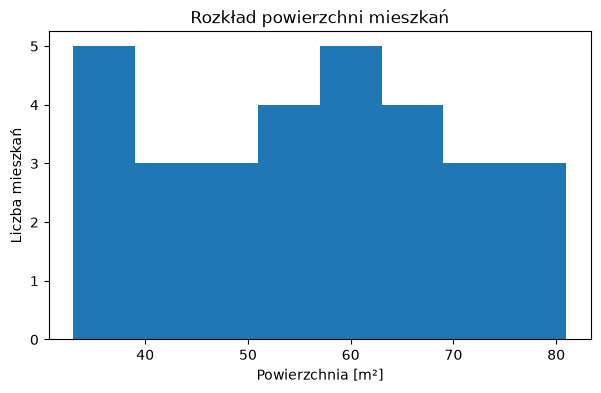

In [93]:
plt.figure(figsize=(7, 4))
plt.hist(df["powierzchnia_m2"], bins=8)
plt.xlabel("Powierzchnia [m²]")
plt.ylabel("Liczba mieszkań")
plt.title("Rozkład powierzchni mieszkań")
plt.show()

**Pytanie do danych:** Czy w zbiorze przeważają mieszkania małe, średnie czy duże?


### Przykład 17. Wykres punktowy

Wykres punktowy jest bardzo użyteczny do obserwowania zależności pomiędzy dwiema zmiennymi numerycznymi.


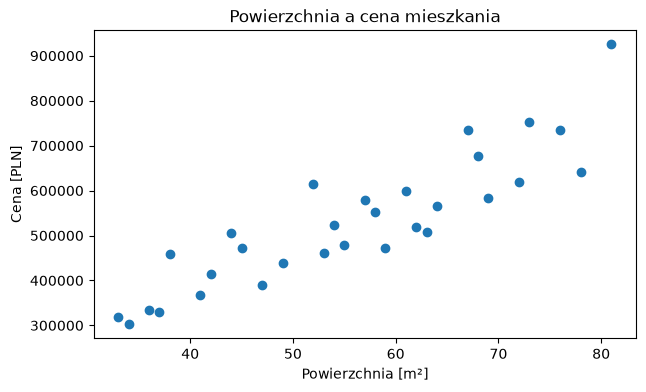

In [94]:
plt.figure(figsize=(7, 4))
plt.scatter(df["powierzchnia_m2"], df["cena_pln"])
plt.xlabel("Powierzchnia [m²]")
plt.ylabel("Cena [PLN]")
plt.title("Powierzchnia a cena mieszkania")
plt.show()

**Interpretacja:** każdy punkt odpowiada jednej obserwacji.  
Możemy sprawdzić, czy wraz ze wzrostem powierzchni cena ma tendencję do wzrostu. Sam wykres pokazuje zależność, ale nie dowodzi związku przyczynowego.


### Przykład 18. Wykres słupkowy

Przedstawmy średnią cenę za metr kwadratowy w grupach wyznaczonych przez dzielnicę.


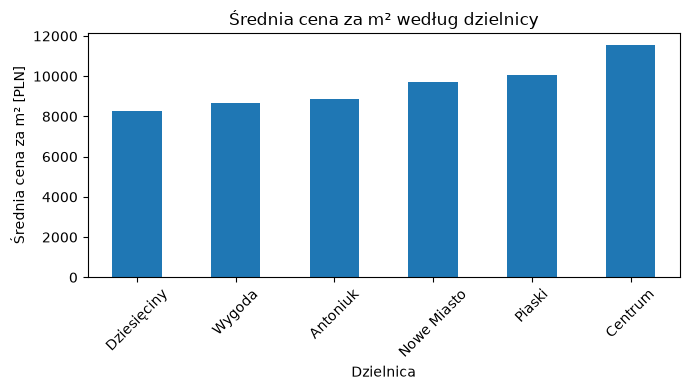

In [95]:
srednie_dzielnice.sort_values().plot(kind="bar", figsize=(7, 4))
plt.xlabel("Dzielnica")
plt.ylabel("Średnia cena za m² [PLN]")
plt.title("Średnia cena za m² według dzielnicy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Mini-analiza: od pliku do wniosku

Typowa pierwsza analiza danych może wyglądać następująco:

1. Wczytaj dane.
2. Sprawdź ich rozmiar i strukturę.
3. Zidentyfikuj brakujące wartości.
4. Wybierz interesujące cechy.
5. Wykonaj proste obliczenia lub agregacje.
6. Zwizualizuj wyniki.
7. Sformułuj wniosek.

To nie jest jeszcze budowanie modelu uczenia maszynowego, ale jest to ważny etap przygotowujący do dalszej analizy.


In [96]:
print("Liczba obserwacji:", len(df))
print("Średnia powierzchnia:", round(df["powierzchnia_m2"].mean(), 2), "m²")
print("Mediana ceny:", round(df["cena_pln"].median(), 2), "PLN")
print("Najmniejsza cena:", df["cena_pln"].min(), "PLN")
print("Największa cena:", df["cena_pln"].max(), "PLN")

Liczba obserwacji: 30
Średnia powierzchnia: 55.6 m²
Mediana ceny: 513500.0 PLN
Najmniejsza cena: 302000 PLN
Największa cena: 925000 PLN


# 6. Zadania do samodzielnego wykonania

W zadaniach korzystaj z obiektu `df` utworzonego wcześniej.  
Nie zmieniaj oryginalnego pliku CSV.

---

### Zadanie 1. NumPy

Utwórz tablicę NumPy:

`[42, 58, 76, 41, 55, 69]`

Następnie:

1. wyświetl jej kształt,
2. oblicz średnią i medianę,
3. wybierz elementy większe niż 55,
4. pomnóż wszystkie wartości przez 2.


In [97]:
# TODO - Zadanie 1
arr = np.array([42, 58, 76, 41, 55, 69])
print(f"Kształt: {arr.shape}")

print(f"Średnia: {np.mean(arr)}")
print(f"Mediana: {np.median(arr)}")

masc = arr > 55
print(arr[masc])

arr = arr * 2
print(arr)

Kształt: (6,)
Średnia: 56.833333333333336
Mediana: 56.5
[58 76 69]
[ 84 116 152  82 110 138]


### Zadanie 2. Rozpoznanie danych

Dla `df`:

1. wyświetl ostatnich 5 obserwacji,
2. podaj liczbę wierszy i kolumn,
3. wyświetl nazwy wszystkich kolumn,
4. sprawdź, w których kolumnach występują braki danych.


In [98]:
# TODO - Zadanie 2
print(df.head())

print(f"\nLiczba wierszy: {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")

print(f"Nazwy kolumn: {df.columns.tolist()}")

print(f"\nBraki danych:\n{df.isna().sum()}")

   id dzielnica  powierzchnia_m2  liczba_pokoi  pietro  rok_budowy  \
0   1   Centrum               38             2       3      2008.0   
1   2   Centrum               52             2       5      2015.0   
2   3   Centrum               67             3       2      1998.0   
3   4    Piaski               45             2       4      2006.0   
4   5    Piaski               61             3       1      2012.0   

   odleglosc_od_centrum_km  cena_pln balkon    cena_za_m2  
0                      0.8    458000    tak  12052.631579  
1                      1.1    615000    tak  11826.923077  
2                      1.5    735000    nie  10970.149254  
3                      2.0    472000    tak  10488.888889  
4                      2.4    598000    tak   9803.278689  

Liczba wierszy: 30
Liczba kolumn: 10
Nazwy kolumn: ['id', 'dzielnica', 'powierzchnia_m2', 'liczba_pokoi', 'pietro', 'rok_budowy', 'odleglosc_od_centrum_km', 'cena_pln', 'balkon', 'cena_za_m2']

Braki danych:
id        

### Zadanie 3. Wybór i filtrowanie

Znajdź mieszkania, które jednocześnie:

- mają co najmniej 3 pokoje,
- kosztują mniej niż 600 000 PLN.

Wyświetl tylko kolumny:
`dzielnica`, `powierzchnia_m2`, `liczba_pokoi`, `cena_pln`.


In [99]:
# TODO - Zadanie 3
df_new = df[(df["liczba_pokoi"] >= 3) & (df["cena_pln"] < 600000)]
df_new[["dzielnica", "powierzchnia_m2", "liczba_pokoi", "cena_pln"]]

,dzielnica,powierzchnia_m2,liczba_pokoi,cena_pln
4,Piaski,61,3,598000
8,Antoniuk,64,3,565000
10,Nowe Miasto,58,3,552000
13,Wygoda,55,3,478000
14,Wygoda,69,3,583000
17,Dziesięciny,63,3,508000
22,Wygoda,62,3,519000
25,Piaski,57,3,579000
29,Dziesięciny,59,3,472000


### Zadanie 4. Nowa kolumna

Utwórz kolumnę `cena_za_pokoj`, obliczoną jako:

cena za pokój = cena mieszkania/ liczba pokoi

Wyświetl pięć pierwszych wartości nowej kolumny.

In [100]:
# TODO - Zadanie 4
df["cena_za_pokoj"] = df["cena_pln"] / df["liczba_pokoi"]
df["cena_za_pokoj"].head()

0    229000.000000
1    307500.000000
2    245000.000000
3    236000.000000
4    199333.333333
Name: cena_za_pokoj, dtype: float64

### Zadanie 5. Grupowanie

Oblicz średnią powierzchnię mieszkań w każdej dzielnicy.

Następnie uporządkuj wynik od największej do najmniejszej średniej powierzchni.


In [101]:
# TODO - Zadanie 5
avg_area = (
    df.groupby("dzielnica")["powierzchnia_m2"]
        .mean()
        .sort_values(ascending=False)
)

avg_area

dzielnica
Nowe Miasto    59.6
Centrum        56.4
Dziesięciny    56.2
Antoniuk       54.8
Piaski         53.8
Wygoda         52.8
Name: powierzchnia_m2, dtype: float64

### Zadanie 6. Histogram

Narysuj histogram zmiennej `cena_pln`.

Dodaj:

- tytuł,
- opis osi X,
- opis osi Y.


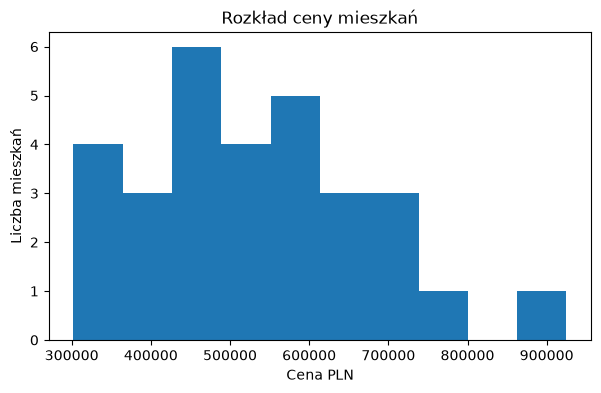

In [102]:
# TODO - Zadanie 6
plt.figure(figsize=(7, 4))
plt.hist(df["cena_pln"])
plt.xlabel("Cena PLN")
plt.ylabel("Liczba mieszkań")
plt.title("Rozkład ceny mieszkań")
plt.show()

### Zadanie 7. Wykres punktowy

Narysuj wykres punktowy:

- oś X: `odleglosc_od_centrum_km`,
- oś Y: `cena_za_m2`.

Pamiętaj, że w kolumnie z odległością występują brakujące wartości.  
Matplotlib pominie punkty, dla których nie ma pełnej pary wartości.

Dodaj tytuł i opisy osi.


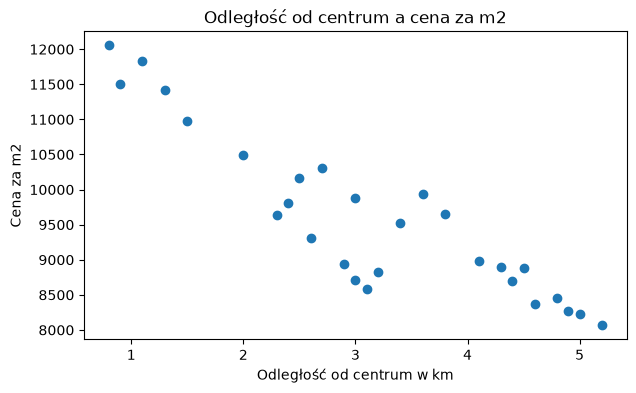

In [103]:
# TODO - Zadanie 7
plt.figure(figsize=(7, 4))
plt.scatter(df["odleglosc_od_centrum_km"], df["cena_za_m2"])
plt.xlabel("Odległość od centrum w km")
plt.ylabel("Cena za m2")
plt.title("Odległość od centrum a cena za m2")
plt.show()

### Zadanie 8. Krótka interpretacja

Na podstawie wykonanych obliczeń i wykresów zapisz **2–3 krótkie obserwacje dotyczące danych**.

**Twoje wnioski:**

1. Najwięcej jest mieszkań z przedziału cenowego 400 000 - 500 000 zł
2. Im bliżej centrum tym wyższa cena za m2
3. Największe mieszkania znajdują się w dzielnicy "Nowe Miasto", średnia około 60m2


## Materiały wykorzystane przy przygotowaniu zajęć

Materiał opracowano w oparciu o książki: 
- Laura Igual, Santi Seguí, *Introduction to Data Science: A Python Approach to Concepts, Techniques and Applications*, Springer International Publishing, 2017, seria Undergraduate Topics in Computer Science. — części dotyczące NumPy, pandas, DataFrame i odczytu danych,
- Piotr Wróblewski, *Machine Learning i Natural Language Processing w programowaniu. Podręcznik z ćwiczeniami w Pythonie*, Helion S.A., 2024 — części dotyczące NumPy, pandas i Matplotlib.